In [79]:
# =========================
# IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.utils import to_categorical

In [80]:
# =========================
# LOAD CSV
# =========================
TRAIN_CSV = Path("../data/processed/train.csv")
VAL_CSV = Path("../data/processed/validation.csv")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

train_df.head()

Train shape: (2684, 3)
Validation shape: (671, 3)


,filepath,label,split
0,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
1,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
2,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
3,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
4,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train


In [81]:
# =========================
# FIX FILEPATHS
# =========================
train_df["filepath"] = train_df["filepath"].str.replace(
    "data/processed/train", "data/raw/RiceLeafs/train", regex=False
)

val_df["filepath"] = val_df["filepath"].str.replace(
    "data/processed/validation", "data/raw/RiceLeafs/validation", regex=False
)

train_df.head()

,filepath,label,split
0,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
1,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
2,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
3,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
4,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train


In [82]:
# =========================
# CLASS WEIGHTS
# =========================
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {i: w for i, w in enumerate(class_weights_array)}

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.605263157894737), 1: np.float64(0.563392107472712), 2: np.float64(1.4845132743362832), 3: np.float64(1.0770465489566614)}


In [83]:
# =========================
#  LABEL ENCODING
# =========================
label_encoder = LabelEncoder()
 
y_train = label_encoder.fit_transform(train_df["label"])
y_val = label_encoder.transform(val_df["label"])
 
class_names = label_encoder.classes_
num_classes = len(class_names)
 
print("Classes:", class_names)
print("Number of classes:", num_classes)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
 
# Sanity check — MUST match
assert X_train.shape[0] == y_train.shape[0], "MISMATCH: X_train and y_train row counts differ!"
assert X_val.shape[0] == y_val.shape[0], "MISMATCH: X_val and y_val row counts differ!"
print("Shape check passed — images and labels are aligned!")

Classes: ['BrownSpot' 'Healthy' 'Hispa' 'LeafBlast']
Number of classes: 4
y_train shape: (2684,)
y_val shape: (671,)
Shape check passed — images and labels are aligned!


In [84]:
# =========================
# CLASS WEIGHTS
# =========================
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
 
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.605263157894737), 1: np.float64(0.563392107472712), 2: np.float64(1.4845132743362832), 3: np.float64(1.0770465489566614)}


In [85]:
# =========================
# PREPROCESS LABELS
# =========================
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
 
print("y_train_cat shape:", y_train_cat.shape)
print("y_val_cat shape:", y_val_cat.shape)

y_train_cat shape: (2684, 4)
y_val_cat shape: (671, 4)


In [86]:
# =========================
# DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),
])

In [87]:
# =========================
# BUILD EFFICIENTNETB0 MODEL
# =========================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False
 
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False) 
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
 
model = models.Model(inputs, outputs)
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
 
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [88]:
# =========================
# CALLBACKS
# =========================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [89]:
# =========================
# FIRST TRAINING PHASE
# =========================
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=15,
    batch_size=32,
    verbose=1,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.2668 - loss: 2.2078 - val_accuracy: 0.2325 - val_loss: 1.4371 - learning_rate: 1.0000e-04
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.2917 - loss: 1.9709 - val_accuracy: 0.2459 - val_loss: 1.4962 - learning_rate: 1.0000e-04
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 999ms/step - accuracy: 0.3290 - loss: 1.7629
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
84/84 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.3431 - loss: 1.7991 - val_accuracy: 0.2489 - val_loss: 1.5956 - learning_rate: 1.0000e-04
Epoch 4/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.3562 - loss: 1.7307 - val_accuracy: 0.2534 - val_loss: 1.7133 - learning_rate: 2.0000e-05
Epoch 5/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 892ms/step - accuracy: 0.3609 - loss: 1.7414
Epoch 5: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
84/84 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.3730 - loss: 1

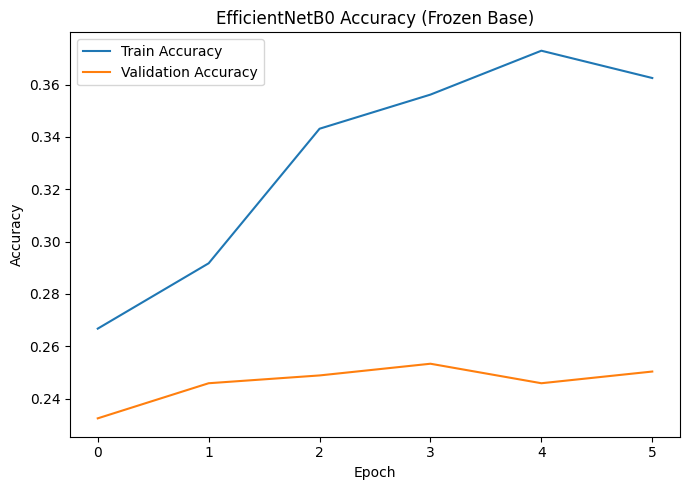

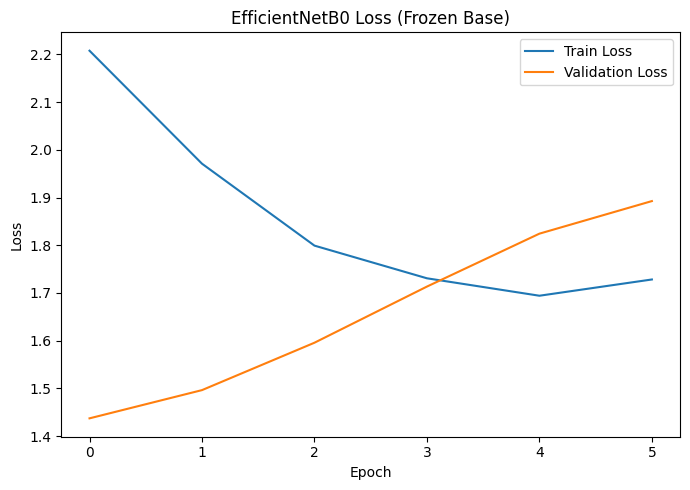

In [90]:
# =========================
# LEARNING CURVES - FIRST PHASE
# =========================
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Accuracy (Frozen Base)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Loss (Frozen Base)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
# =========================
# FINE-TUNING PHASE
# =========================
base_model.trainable = True
 
for layer in base_model.layers[:-50]:
    layer.trainable = False
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
 
fine_tune_history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=25,
    initial_epoch=history.epoch[-1] + 1,
    batch_size=32,
    verbose=1,
    class_weight=class_weights,
    callbacks=callbacks
)
 

Epoch 7/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.2671 - loss: 2.2063 - val_accuracy: 0.2295 - val_loss: 1.5653 - learning_rate: 1.0000e-05
Epoch 8/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2960 - loss: 2.0472
Epoch 8: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
84/84 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.3081 - loss: 2.0397 - val_accuracy: 0.2563 - val_loss: 1.7934 - learning_rate: 1.0000e-05
Epoch 9/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.3126 - loss: 1.9844 - val_accuracy: 0.2519 - val_loss: 1.9863 - learning_rate: 2.0000e-06
Epoch 10/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3115 - loss: 1.9877
Epoch 10: ReduceLROnPlateau reducing learning rate to 1e-06.
84/84 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.3070 - loss: 1.9594 - val_accuracy: 0.2504 - val_loss: 2.1080 - learning_rate: 2.0000e-06
Epoch 11/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.3387 - loss: 1.8537 - val_accur

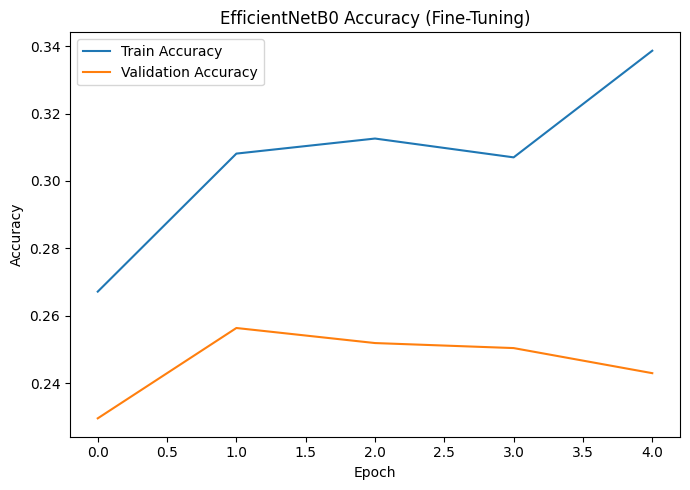

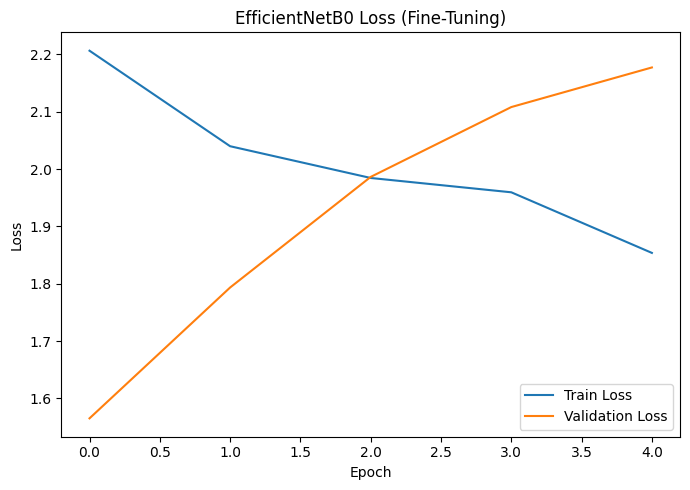

In [92]:
# =========================
# LEARNING CURVES - FINE TUNING
# =========================
plt.figure(figsize=(7, 5))
plt.plot(fine_tune_history.history["accuracy"], label="Train Accuracy")
plt.plot(fine_tune_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Accuracy (Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(fine_tune_history.history["loss"], label="Train Loss")
plt.plot(fine_tune_history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Loss (Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [93]:
# =========================
# EVALUATION
# =========================
val_probs = model.predict(X_val)
val_pred = np.argmax(val_probs, axis=1)

eff_acc = accuracy_score(y_val, val_pred)
eff_f1 = f1_score(y_val, val_pred, average="macro")

print("EfficientNetB0 Accuracy:", round(eff_acc, 4))
print("EfficientNetB0 Macro-F1:", round(eff_f1, 4))

21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 844ms/step
EfficientNetB0 Accuracy: 0.2295
EfficientNetB0 Macro-F1: 0.2274


In [94]:
# =========================
# CLASSIFICATION REPORT
# =========================
print(classification_report(y_val, val_pred, target_names=class_names))

              precision    recall  f1-score   support

   BrownSpot       0.18      0.30      0.23       105
     Healthy       0.37      0.11      0.17       297
       Hispa       0.21      0.53      0.30       113
   LeafBlast       0.25      0.19      0.21       156

    accuracy                           0.23       671
   macro avg       0.25      0.28      0.23       671
weighted avg       0.29      0.23      0.21       671



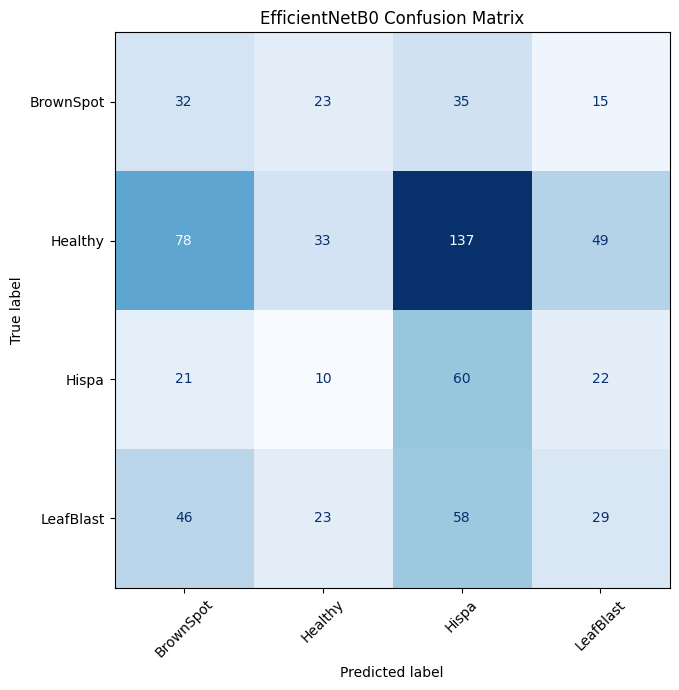

In [95]:
# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_val, val_pred)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("EfficientNetB0 Confusion Matrix")
plt.tight_layout()
plt.show()

In [96]:
# =========================
# RESULTS TABLE
# =========================
results_df = pd.DataFrame({
    "Model": ["EfficientNetB0"],
    "Accuracy": [eff_acc],
    "Macro-F1": [eff_f1]
})

results_df

,Model,Accuracy,Macro-F1
0,EfficientNetB0,0.229508,0.227431
